# ANN Model for Deep Learning - Movie Collection Prediction

In [1]:
#Importing the required libraries for modeling
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#importing DL libraries for ANN modeling
import tensorflow as tf
from tensorflow import keras

In [3]:
#Importing the Independent and Dependent datasets
data_x = pd.read_csv("C:/Users/Manish Gupta/Desktop/Movie_collection_Independent.csv")
data_y = pd.read_csv("C:/Users/Manish Gupta/Desktop/Movie_collection_Target.csv")

In [4]:
#Getting insight of imported Datasets
data_x.shape

(506, 19)

In [5]:
data_y.shape

(506, 1)

In [6]:
data_x.head()

,Marketin_expense,Production_expense,Multiplex_coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,3D_available,Genre_Thriller,Genre_Drama,Genre_Comedy
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,109.60,223.840,23,494,1,1,0,0
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,146.64,243.456,42,462,0,0,1,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,147.88,2022.400,38,458,0,0,0,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,185.36,225.344,45,472,1,0,1,0
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,176.48,225.792,55,395,0,0,1,0


In [7]:
data_y.head()

,Collection
0,2.266667
1,2.106667
2,2.980000
3,2.893333
4,3.080000


In [8]:
#Analysis of given Datasets
data_x.columns

Index(['Marketin_expense', 'Production_expense', 'Multiplex_coverage',
       'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating',
       'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views',
       'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex',
       '3D_available', 'Genre_Thriller', 'Genre_Drama', 'Genre_Comedy'],
      dtype='object')

In [9]:
data_x.describe()

,Marketin_expense,Production_expense,Multiplex_coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,3D_available,Genre_Thriller,Genre_Drama,Genre_Comedy
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,92.270471,77.273557,0.445305,34911.144022,142.074901,8.014002,8.185613,8.019664,8.190514,7.810870,449860.715415,157.218182,260.832095,39.181818,545.043478,0.551383,0.361660,0.191700,0.306324
std,172.030902,13.720706,0.115878,3903.038232,28.148861,1.054266,1.054290,1.059899,1.049601,0.659699,68917.763145,31.169624,104.779133,12.513697,106.332889,0.497845,0.480957,0.394028,0.461422
min,20.126400,55.920000,0.129000,19781.355000,76.400000,3.840000,4.035000,3.840000,4.030000,6.600000,212912.000000,0.000000,201.152000,3.000000,333.000000,0.000000,0.000000,0.000000,0.000000
25%,21.640900,65.380000,0.376000,32693.952500,118.525000,7.316250,7.503750,7.296250,7.507500,7.200000,409128.000000,132.490000,223.796000,28.000000,465.000000,0.000000,0.000000,0.000000,0.000000
50%,25.130200,74.380000,0.462000,34488.217500,151.000000,8.307500,8.495000,8.312500,8.465000,7.960000,462460.000000,159.980000,254.400000,39.000000,535.500000,1.000000,0.000000,0.000000,0.000000
75%,93.541650,91.200000,0.551000,36793.542500,167.575000,8.865000,9.030000,8.883750,9.030000,8.260000,500247.500000,181.610000,283.416000,50.000000,614.750000,1.000000,1.000000,0.000000,1.000000
max,1799.524000,110.480000,0.615000,48772.900000,173.500000,9.435000,9.540000,9.425000,9.635000,9.400000,567784.000000,217.520000,2022.400000,60.000000,868.000000,1.000000,1.000000,1.000000,1.000000


### Splitting datasets into training, test and validation sets

In [10]:
# Importing the train test split function
from sklearn.model_selection import train_test_split
train_x_full,test_x,train_y_full,test_y = train_test_split(data_x,data_y, random_state = 42)
train_x, valid_x, train_y, valid_y = train_test_split(train_x_full,train_y_full, random_state = 42)

In [11]:
#Analysing train, test and validation datasets
train_x.shape

(284, 19)

In [12]:
valid_x.shape

(95, 19)

In [13]:
test_x.shape

(127, 19)

### Standardizing the Data

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x)
valid_x = scaler.transform(valid_x)
test_x = scaler.transform(test_x)

In [15]:
np.random.seed(42)
tf.random.set_seed(42)

## Building the ANN Model as per problem Description

In [16]:
model = keras.models.Sequential()
model.add(keras.layers.Dense(30, activation="relu", input_shape=[19]))
model.add(keras.layers.Dense(30, activation="relu"))
model.add(keras.layers.Dense(1))

#### Compiling the Model

In [17]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(lr=1e-2), metrics=["mae"])

In [18]:
#Converting the datasets from being a numpy array to pandas dataframes suitable for training and fitting the model
train_x = pd.DataFrame(train_x)
train_y = pd.DataFrame(train_y)
valid_x = pd.DataFrame(valid_x)
valid_y = pd.DataFrame(valid_y)

#### Training the model for 100 epochs

In [19]:
model_history = model.fit(train_x, train_y, epochs=100, validation_data=(valid_x, valid_y))

Train on 284 samples, validate on 95 samples
Epoch 1/100
284/284 [==============================] - 0s 557us/sample - loss: 3.6884 - mae: 1.6615 - val_loss: 1.5386 - val_mae: 1.0385
Epoch 2/100
284/284 [==============================] - 0s 96us/sample - loss: 0.8042 - mae: 0.7132 - val_loss: 0.7881 - val_mae: 0.7032
Epoch 3/100
284/284 [==============================] - 0s 98us/sample - loss: 0.5324 - mae: 0.5682 - val_loss: 0.5688 - val_mae: 0.5944
Epoch 4/100
284/284 [==============================] - 0s 102us/sample - loss: 0.4050 - mae: 0.4979 - val_loss: 0.4445 - val_mae: 0.5293
Epoch 5/100
284/284 [==============================] - 0s 98us/sample - loss: 0.3212 - mae: 0.4338 - val_loss: 0.3577 - val_mae: 0.4749
Epoch 6/100
284/284 [==============================] - 0s 102us/sample - loss: 0.2679 - mae: 0.3950 

### Plotting the Model Curve

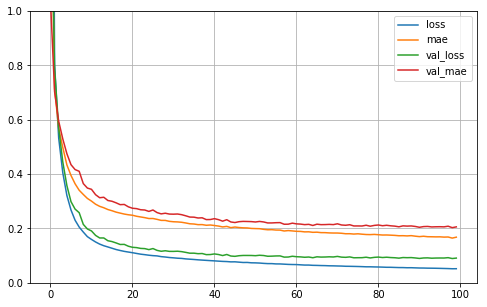

In [20]:
#Plotting curve to see model rgence and finding best possible modeling epoch
pd.DataFrame(model_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

### Saving the model built and trained so far in %pwd - present working directory

In [22]:
model.save("MovieCollectionPred-Model.h5")

## Evaluating the Model on Test data

In [23]:
#Converting Test data to Dataframes for Avoiding Conflict of datasets as done above for train and valid sets
test_x = pd.DataFrame(test_x)
test_y = pd.DataFrame(test_y)

In [24]:
mae_test = model.evaluate(test_x, test_y)

127/127 [==============================] - 0s 55us/sample - loss: 0.2728 - mae: 0.2779


In [25]:
#Viewing the loss and metrics in model fitting
model_history.history

{'loss': [3.6883926492341805,
  0.8042497618097655,
  0.5323869308955232,
  0.40495456944049246,
  0.3211831784164402,
  0.26791419823404766,
  0.2301980624316444,
  0.20502591741756654,
  0.18668548070209126,
  0.16978591911389795,
  0.15956537005767016,
  0.1502021870142977,
  0.14235049863936197,
  0.13641697315263077,
  0.13186009144279318,
  0.1271656869162976,
  0.12244604276099676,
  0.11885796970045062,
  0.11562317116579539,
  0.1131428060397296,
  0.1107095600643628,
  0.10798617378926613,
  0.10533455475954942,
  0.1035194608946921,
  0.10147259394887467,
  0.09993573414607787,
  0.09894671070743614,
  0.09629238218488828,
  0.09485850262809807,
  0.0929775939021312,
  0.09186109318070008,
  0.09046296932747666,
  0.08970325901894502,
  0.08792065472250253,
  0.08683166317117046,
  0.08579560033452342,
  0.08452440614641553,
  0.08352317073395554,
  0.08254385550676936,
  0.08158077918727633,
  0.0806716362565336,
  0.07966956538213811,
  0.07872761423948785,
  0.07817466174

### Predicting values of 5 test records, using them as a new alias

In [26]:
new_x = test_x[:5]

In [27]:
#Predicting and Comparing first 5 predicted and actual tesalues by model
pred_y = model.predict(new_x)
print(pred_y)
print(test_y[:5])

[[2.49868  ]
 [2.6638517]
 [1.8319601]
 [2.4707212]
 [1.7485701]]
     Collection
173    2.240000
274    2.826667
491    1.573333
72     2.186667
452    1.740000


## Created, Developed, Designed and Manifested by - Manish Gupta ©